In [1]:
import json
from collections import defaultdict

with open("graph/solar_graphs.json") as f:
    articles = json.load(f)

nodes = {}
edges = []

for article in articles:
    edges.extend(article["edges"])

    for node in article["nodes"]:
        if node["id"] not in nodes:
            nodes[node["id"]] = node

print(f"{len(nodes)} nodes")
print(f"{len(edges)} edges")


4988 nodes
5918 edges


In [2]:
neighbors = defaultdict(set)

for edge in edges:
    neighbors[edge["source"]].add(edge["target"])
    neighbors[edge["target"]].add(edge["source"])


In [3]:
def node_text(node):

    text = []

    text.append(node["type"])

    if node["properties"]["name"]:
        text.append(node["properties"]["name"])

    text.extend(node["mentions"])

    for k, v in node["properties"].items():
        if k == "name":
            continue

        if v:
            text.append(str(v))

    return " ".join(text)


In [4]:
by_type = defaultdict(list)

for node in nodes.values():
    by_type[node["type"]].append(node)


In [5]:
%pip install -U sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
import os

load_dotenv()

login(token=os.environ["HF_TOKEN"])


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("BAAI/bge-large-en-v1.5")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [8]:
%pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [9]:
from rapidfuzz import fuzz

def normalize(name):

    name = name.lower()

    replacements = [
        "inc.",
        "inc",
        "corp.",
        "corporation",
        "company",
        "co.",
        ".com",
        "ltd",
        "limited",
        "motors"
    ]

    for r in replacements:
        name = name.replace(r, "")

    return " ".join(name.split())


def mention_similarity(a, b):

    a = set(m.lower() for m in a)
    b = set(m.lower() for m in b)

    if not a or not b:
        return 0

    return len(a & b) / len(a | b)


In [10]:
%pip install faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [11]:
import faiss
import numpy as np

candidate_pairs = []

for entity_type, group in by_type.items():

    texts = [node_text(n) for n in group]

    embeddings = model.encode(
        texts,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    embeddings = np.asarray(embeddings).astype("float32")

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    D, I = index.search(embeddings, 6)

    for i in range(len(group)):

        node1 = group[i]

        for j in range(1, 6):

            idx = I[i][j]

            node2 = group[idx]

            emb_score = float(D[i][j])

            name_score = (
                fuzz.token_sort_ratio(
                    normalize(node1["properties"]["name"]),
                    normalize(node2["properties"]["name"])
                )
                / 100
            )

            mention_score = mention_similarity(
                node1["mentions"],
                node2["mentions"]
            )

            score = (
                0.6 * emb_score
                + 0.3 * name_score
                + 0.1 * mention_score
            )

            if score > 0.88:

                candidate_pairs.append(
                    (
                        node1["id"],
                        node2["id"],
                        score
                    )
                )


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

In [12]:
import networkx as nx

G = nx.Graph()

for node in nodes:
    G.add_node(node)

for a, b, score in candidate_pairs:
    G.add_edge(a, b, weight=score)

clusters = list(nx.connected_components(G))

print(len(clusters))


4931


In [13]:
canonical = {}

for cluster in clusters:

    if len(cluster) == 1:
        continue

    members = [nodes[c] for c in cluster]

    winner = max(
        members,
        key=lambda n: len(n["properties"]["name"])
    )

    for m in members:

        if m["id"] != winner["id"]:
            canonical[m["id"]] = winner["id"]


In [14]:
def resolve(node):

    while node in canonical:
        node = canonical[node]

    return node


for edge in edges:

    edge["source"] = resolve(edge["source"])
    edge["target"] = resolve(edge["target"])


In [15]:
seen = set()
new_edges = []

for e in edges:

    key = (
        e["source"],
        e["target"],
        e["relationship"]
    )

    if key not in seen:
        seen.add(key)
        new_edges.append(e)

edges = new_edges


In [16]:
new_nodes = []

for node in nodes.values():

    if node["id"] not in canonical:
        new_nodes.append(node)


In [17]:
with open("merged_graph.json", "w") as f:

    json.dump(
        {
            "nodes": new_nodes,
            "edges": edges
        },
        f,
        indent=2
    )


In [18]:
node_ids = {n["id"] for n in new_nodes}

bad_edges = []

for edge in edges:
    if edge["source"] not in node_ids or edge["target"] not in node_ids:
        bad_edges.append(edge)

print(f"Invalid edges: {len(bad_edges)}")


Invalid edges: 94


In [ ]:
%pip install pyvis

Note: you may need to restart the kernel to use updated packages.


: 

In [ ]:
import json
from pyvis.network import Network

# Load merged graph
with open("merged_graph.json", "r") as f:
    graph = json.load(f)

nodes = graph["nodes"]
edges = graph["edges"]

# Create network
net = Network(
    height="900px",
    width="100%",
    bgcolor="#ffffff",
    font_color="black",
    directed=True,
)

# Physics settings
net.barnes_hut()

# Colors by node type
COLORS = {
    "Person": "#ff9999",
    "Company": "#66b3ff",
    "Organization": "#99ff99",
    "GovernmentAgency": "#ffcc66",
    "Technology": "#c299ff",
    "Location": "#ffd966",
    "Policy": "#f4cccc",
    "Event": "#d9ead3"
}

# ------------------------
# Add nodes
# ------------------------

for node in nodes:

    node_id = node["id"]

    name = node["properties"].get("name", node_id)

    node_type = node["type"]

    tooltip = f"""
<b>{name}</b><br>
Type: {node_type}<br><br>
Mentions:<br>
"""

    for mention in node.get("mentions", []):
        tooltip += f"- {mention}<br>"

    for k, v in node["properties"].items():
        if v and k != "name":
            tooltip += f"<b>{k}</b>: {v}<br>"

    net.add_node(
        node_id,
        label=name,
        title=tooltip,
        color=COLORS.get(node_type, "#cccccc"),
        size=20,
    )

# ------------------------
# Add edges
# ------------------------

for edge in edges:

    net.add_edge(
        edge["source"],
        edge["target"],
        label=edge["relationship"],
        title=edge.get("evidence", ""),
        arrows="to",
    )

# Improve layout
net.set_options("""
{
  "nodes": {
    "shape": "dot",
    "font": {
      "size": 18
    }
  },

  "edges": {
    "font": {
      "size": 12,
      "align": "middle"
    },
    "smooth": {
      "type": "dynamic"
    }
  },

  "physics": {
    "enabled": true,
    "barnesHut": {
      "gravitationalConstant": -6000,
      "springLength": 150
    }
  }
}
""")

# Save
net.write_html("knowledge_graph.html")

print("Saved knowledge_graph.html")


In [ ]:
%pip install pandas sentence-transformers faiss-cpu rapidfuzz networkx

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ast
import pandas as pd

nodes = pd.read_csv("graph/nodes.csv")
edges = pd.read_csv("graph/edges.csv")

# Convert the stringified dict/list columns back to Python objects
nodes["properties"] = nodes["properties"].apply(ast.literal_eval)
nodes["mentions"] = nodes["mentions"].apply(ast.literal_eval)

print(len(nodes), "nodes")
print(len(edges), "edges")


9920 nodes
5918 edges


In [ ]:
import re

REMOVE_WORDS = {
    "inc","inc.","corp","corp.","corporation",
    "company","co","co.","ltd","limited",
    "motors",".com"
}

def normalize(name):

    if not isinstance(name, str):
        return ""

    name = name.lower()

    name = re.sub(r"[^\w\s]", " ", name)

    words = [
        w for w in name.split()
        if w not in REMOVE_WORDS
    ]

    return " ".join(words)


In [ ]:
def build_text(row):

    props = row["properties"]

    text = [
        row["type"],
        props.get("name","")
    ]

    text.extend(row["mentions"])

    for k,v in props.items():
        if k=="name":
            continue

        if v:
            text.append(str(v))

    return " ".join(text)

nodes["text"] = nodes.apply(build_text,axis=1)


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    nodes["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/310 [00:00<?, ?it/s]

In [ ]:
import faiss
import numpy as np

embeddings = np.asarray(embeddings,dtype=np.float32)

index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

D,I = index.search(embeddings,6)


In [ ]:
from rapidfuzz import fuzz

pairs=[]

for i,row in nodes.iterrows():

    for j in I[i][1:]:

        other = nodes.iloc[j]

        # never merge different types
        if row["type"] != other["type"]:
            continue

        emb = float(np.dot(embeddings[i],embeddings[j]))

        name = fuzz.token_sort_ratio(
            normalize(row["properties"]["name"]),
            normalize(other["properties"]["name"])
        )/100

        m1 = {m.lower() for m in row["mentions"]}
        m2 = {m.lower() for m in other["mentions"]}

        mention = 0

        if len(m1|m2):
            mention = len(m1&m2)/len(m1|m2)

        score = (
            0.6*emb +
            0.3*name +
            0.1*mention
        )

        if score>0.90:
            pairs.append(
                (
                    row["id"],
                    other["id"],
                    score
                )
            )

print(len(pairs),"candidate merges")


19965 candidate merges


In [ ]:
import networkx as nx

G = nx.Graph()

G.add_nodes_from(nodes["id"])

for a,b,s in pairs:
    G.add_edge(a,b)

clusters = list(nx.connected_components(G))

print("clusters:",len(clusters))


clusters: 4906


In [ ]:
canonical = {}

for cluster in clusters:

    if len(cluster)==1:
        continue

    group = nodes[
        nodes["id"].isin(cluster)
    ]

    winner = max(
        group.to_dict("records"),
        key=lambda x: (
            len(x["mentions"]),
            len(x["properties"]["name"])
        )
    )

    winner = winner["id"]

    for node in cluster:

        canonical[node]=winner

print(len(canonical),"nodes merged")


147 nodes merged


In [ ]:
edges["source"] = edges["source"].map(
    lambda x: canonical.get(x,x)
)

edges["target"] = edges["target"].map(
    lambda x: canonical.get(x,x)
)


In [ ]:
edges = edges.drop_duplicates(
    subset=[
        "source",
        "target",
        "relationship"
    ]
)


In [ ]:
used = set(edges["source"]) | set(edges["target"])

nodes = nodes[
    nodes["id"].isin(used)
].copy()

nodes = nodes.drop_duplicates(
    subset="id"
)


In [ ]:
missing = (
    set(edges["source"])
    | set(edges["target"])
) - set(nodes["id"])

print(f"{len(missing)} missing nodes")

for m in sorted(missing):
    print(m)


77 missing nodes
article_id
company:china
company:global_fossil_fuel_companies
company:ilioss
company:paramount_solar
company:range_fuels
company:silverado_power_llc
company:software_and_data_providers
company:solar_grid_storage
company:sunedison_frontier_power
company:sunverge_energy
company:thermal_power_research_institute
location:1600_pennsylvania_ave
location:coal_communities
location:global
location:maui
location:near_boulder_city_nev
location:qinghai_plateau
location:san_antonio
location:san_luis_obispo
location:severn_estuary
location:south_london
location:sunset_park
location:university_of_california_at_davis
location:west_harlem
location:world
location:yerington
location:yuma_county_arizona
location:zhengzhou
policy:2c_degree_policy
policy:demand_charges
policy:green_energy_initiatives
policy:obama_administration
policy:renewable_energy
policy:retail_rate_credits
project:15th_century_barn_renovation
project:31_proposed_projects
project:african_rift_geothermal_development_faci

In [ ]:
original = pd.read_csv("graph/nodes.csv")

original_ids = set(original["id"])

missing = (
    set(edges["source"])
    | set(edges["target"])
) - set(nodes["id"])

for m in sorted(missing):
    print(m, m in original_ids)


article_id False
company:china False
company:global_fossil_fuel_companies False
company:ilioss False
company:paramount_solar False
company:range_fuels False
company:silverado_power_llc False
company:software_and_data_providers False
company:solar_grid_storage False
company:sunedison_frontier_power False
company:sunverge_energy False
company:thermal_power_research_institute False
location:1600_pennsylvania_ave False
location:coal_communities False
location:global False
location:maui False
location:near_boulder_city_nev False
location:qinghai_plateau False
location:san_antonio False
location:san_luis_obispo False
location:severn_estuary False
location:south_london False
location:sunset_park False
location:university_of_california_at_davis False
location:west_harlem False
location:world False
location:yerington False
location:yuma_county_arizona False
location:zhengzhou False
policy:2c_degree_policy False
policy:demand_charges False
policy:green_energy_initiatives False
policy:obama_admin

In [ ]:
new_nodes = []

for node_id in missing:

    if ":" in node_id:
        node_type, name = node_id.split(":", 1)
    else:
        node_type = "Unknown"
        name = node_id

    node_type = node_type.capitalize()

    pretty = (
        name.replace("_", " ")
            .replace("-", " ")
            .title()
    )

    new_nodes.append({
        "id": node_id,
        "type": node_type,
        "properties": {
            "name": pretty
        },
        "mentions": [],
        "article_id": None
    })

nodes = pd.concat(
    [nodes, pd.DataFrame(new_nodes)],
    ignore_index=True
)


In [ ]:
missing = (
    set(edges["source"])
    | set(edges["target"])
) - set(nodes["id"])

print(missing)


set()


In [ ]:
nodes.to_csv(
    "merged_nodes.csv",
    index=False
)

edges.to_csv(
    "merged_edges.csv",
    index=False
)


In [ ]:
from pyvis.network import Network
import pandas as pd
import ast

# Reload nodes if necessary
nodes = pd.read_csv("merged_nodes.csv")
edges = pd.read_csv("merged_edges.csv")

# Parse properties if still stored as strings
nodes["properties"] = nodes["properties"].apply(ast.literal_eval)

net = Network(
    notebook=True,
    height="800px",
    width="100%",
    directed=True,
    bgcolor="white"
)

colors = {
    "Person": "#ff9999",
    "Company": "#66b3ff",
    "Organization": "#99ff99",
    "Governmentagency": "#ffcc66",
    "GovernmentAgency": "#ffcc66",
    "Technology": "#c299ff",
    "Location": "#ffd966",
    "Policy": "#f4cccc",
    "Project": "#a2d5f2",
    "Source": "#cccccc"
}

# Add nodes
for _, row in nodes.iterrows():
    name = row["properties"].get("name", row["id"])

    net.add_node(
        row["id"],
        label=name,
        title=f"{row['type']}<br>{row['id']}",
        color=colors.get(row["type"], "#cccccc")
    )

# Add edges
for _, row in edges.iterrows():
    net.add_edge(
        row["source"],
        row["target"],
        title=row["relationship"]
    )

Original: 4002 nodes, 5127 edges
Filtered: 1559 nodes, 2869 edges


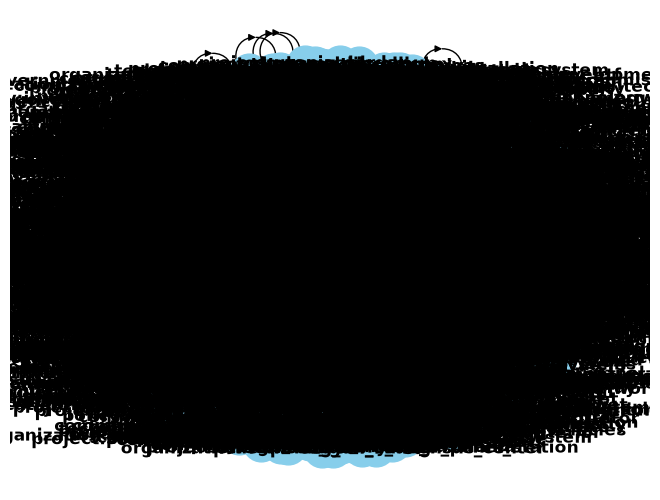

In [6]:
import pandas as pd
from graph_utils import build_networkx_graph, summarize_graph
import matplotlib.pyplot as plt
import networkx as nx
nodes = pd.read_csv("merged_nodes.csv")
edges = pd.read_csv("merged_edges.csv")
# Build the graph from the existing edge data used earlier in the notebook
graph, filtered_graph, nodes_to_keep = build_networkx_graph(edges, nodes=nodes, min_degree=2)
summarize_graph(graph, filtered_graph)
nx.draw(filtered_graph, with_labels=True, node_color="skyblue", node_size=700, font_weight="bold")

# 4. Display the window
plt.show()


In [5]:
from graph_notebook_runner import build_and_report_graph

graph, filtered_graph, nodes_to_keep, nodes = build_and_report_graph(min_degree=20)
print(filtered_graph.number_of_nodes(), filtered_graph.number_of_edges())

Original: 4002 nodes, 5127 edges
Filtered: 45 nodes, 234 edges
45 234


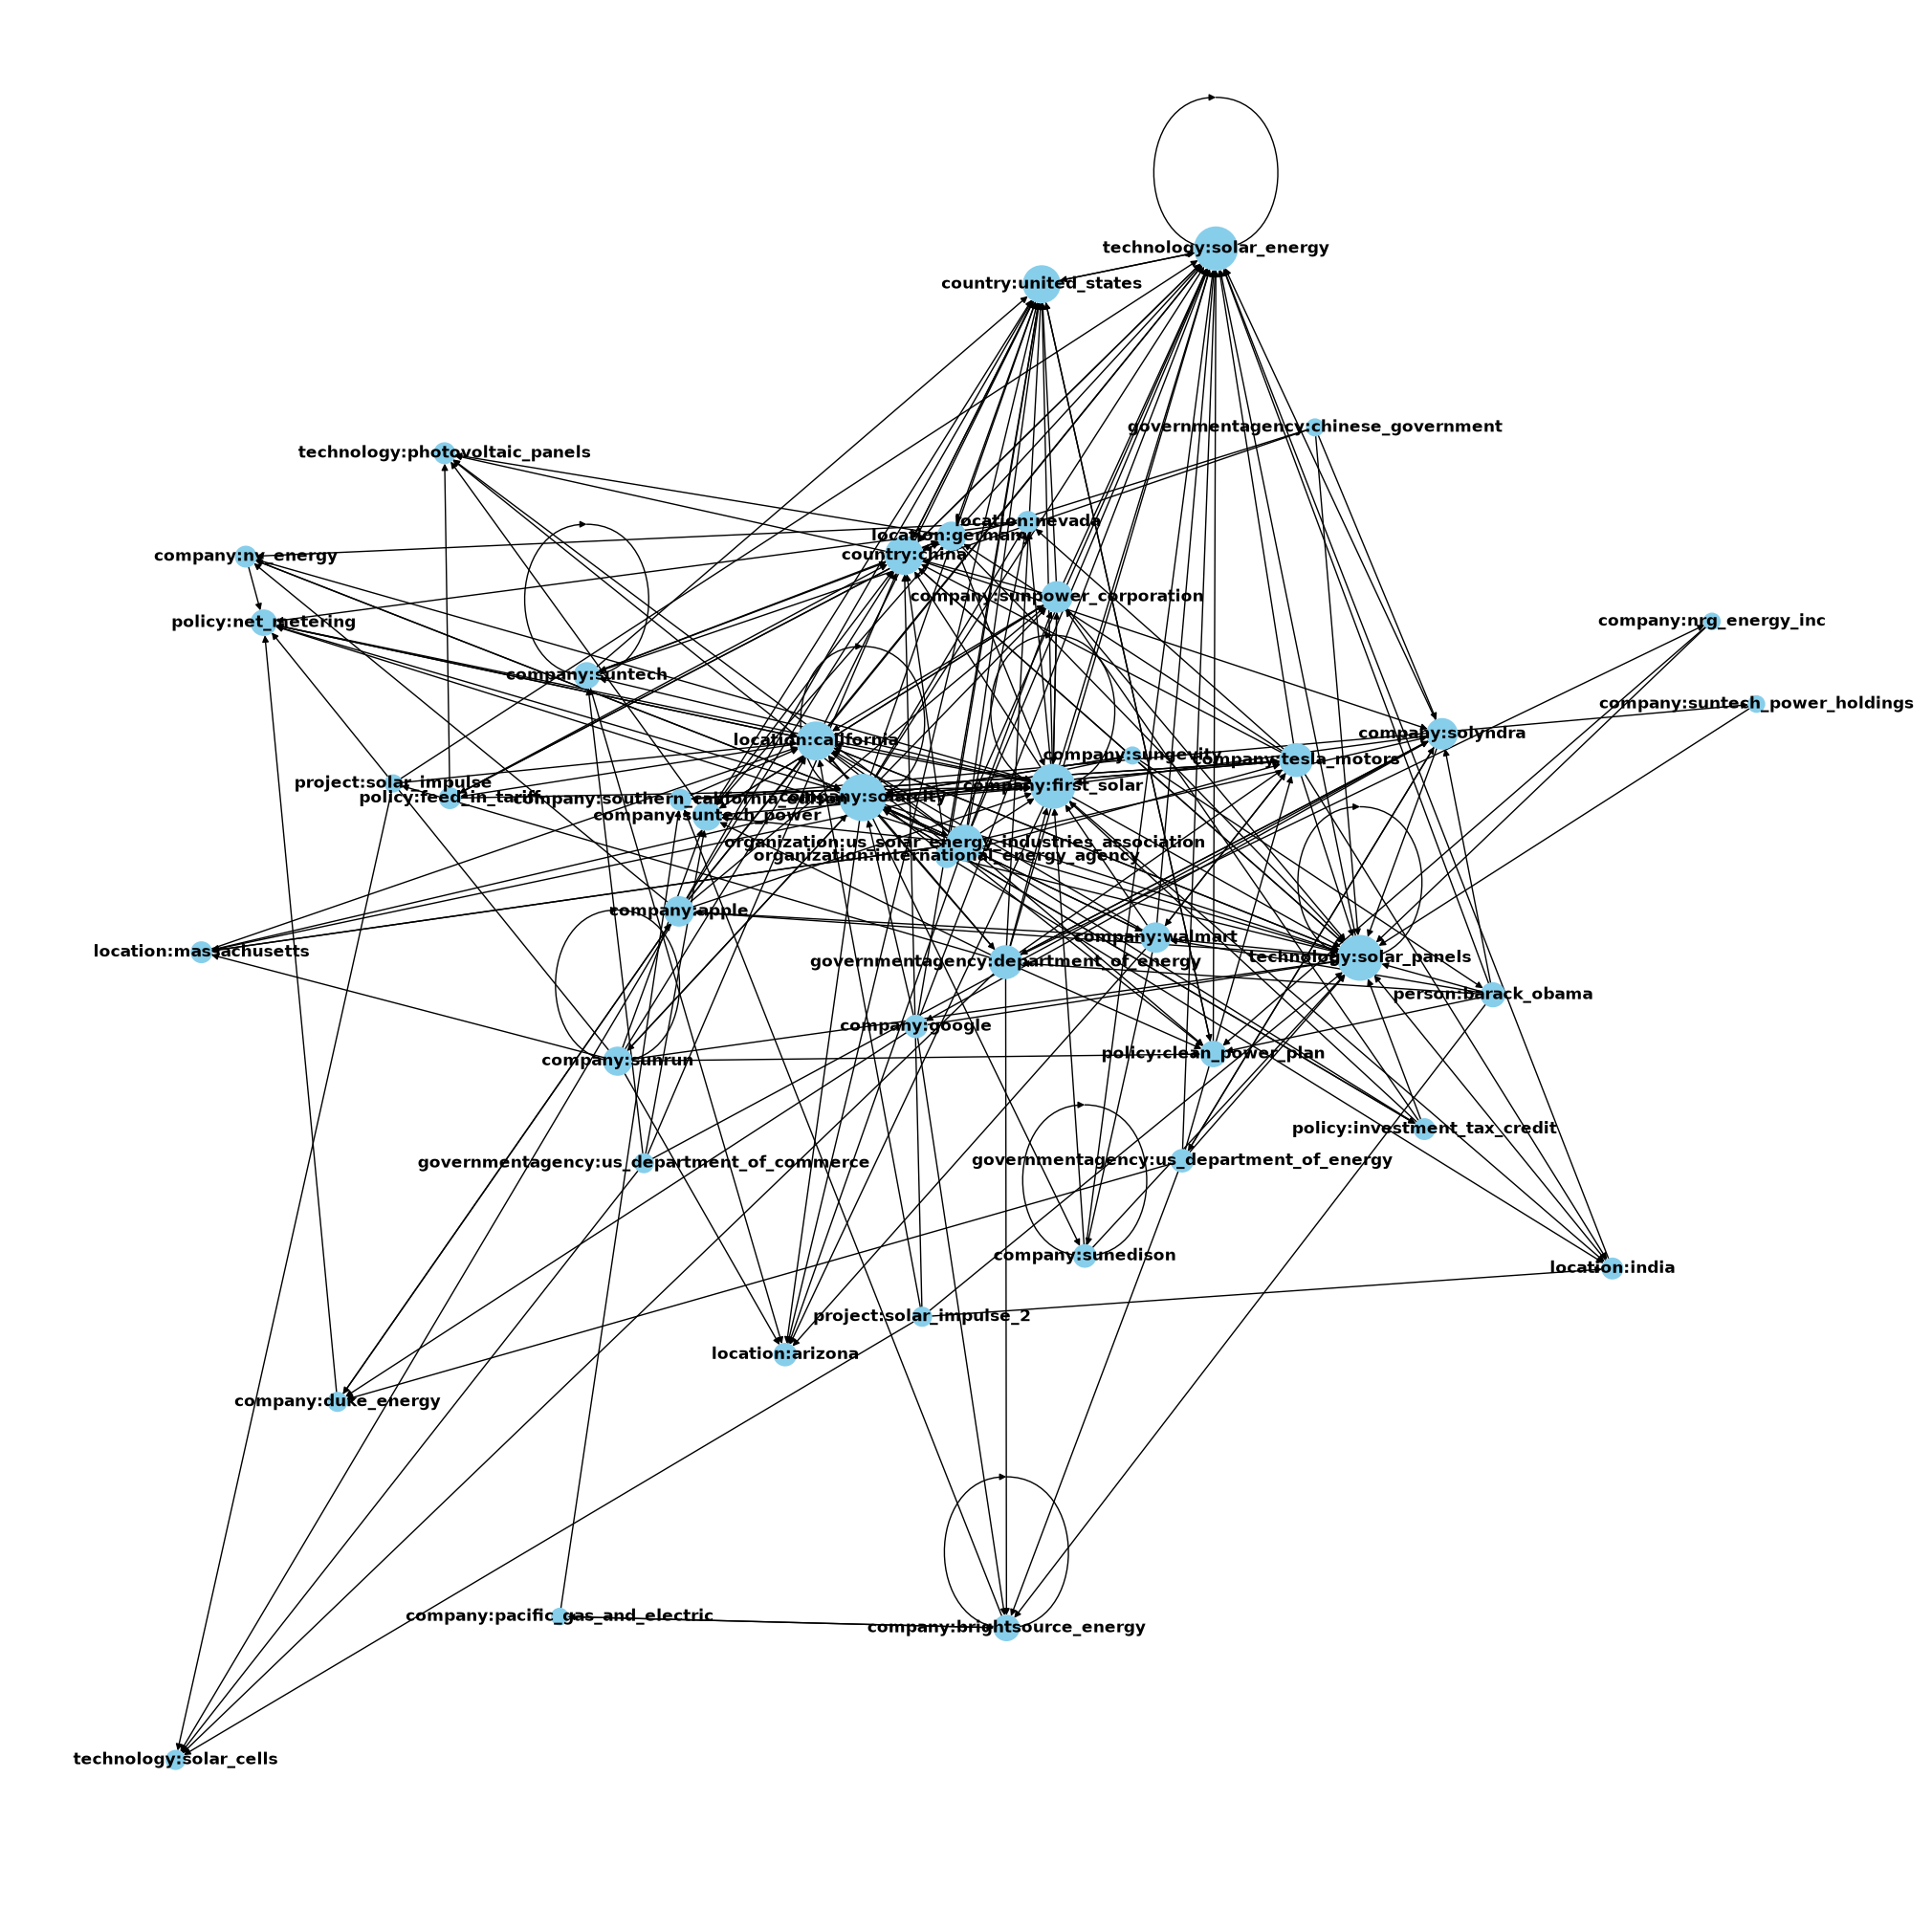

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

# Draw the filtered graph using the same threshold as the previous cell
# Scale node sizes by their degree so more connected nodes appear larger.
degree_values = dict(filtered_graph.degree())
node_sizes = [max(150, degree_values[node] * 40) for node in filtered_graph.nodes()]
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(filtered_graph, k=0.8, iterations=50)

nx.draw(
    filtered_graph,
    pos=pos,
    with_labels=True,
    node_color="skyblue",
    node_size=node_sizes,
    font_weight="bold",
)

# 4. Display the window
plt.show()


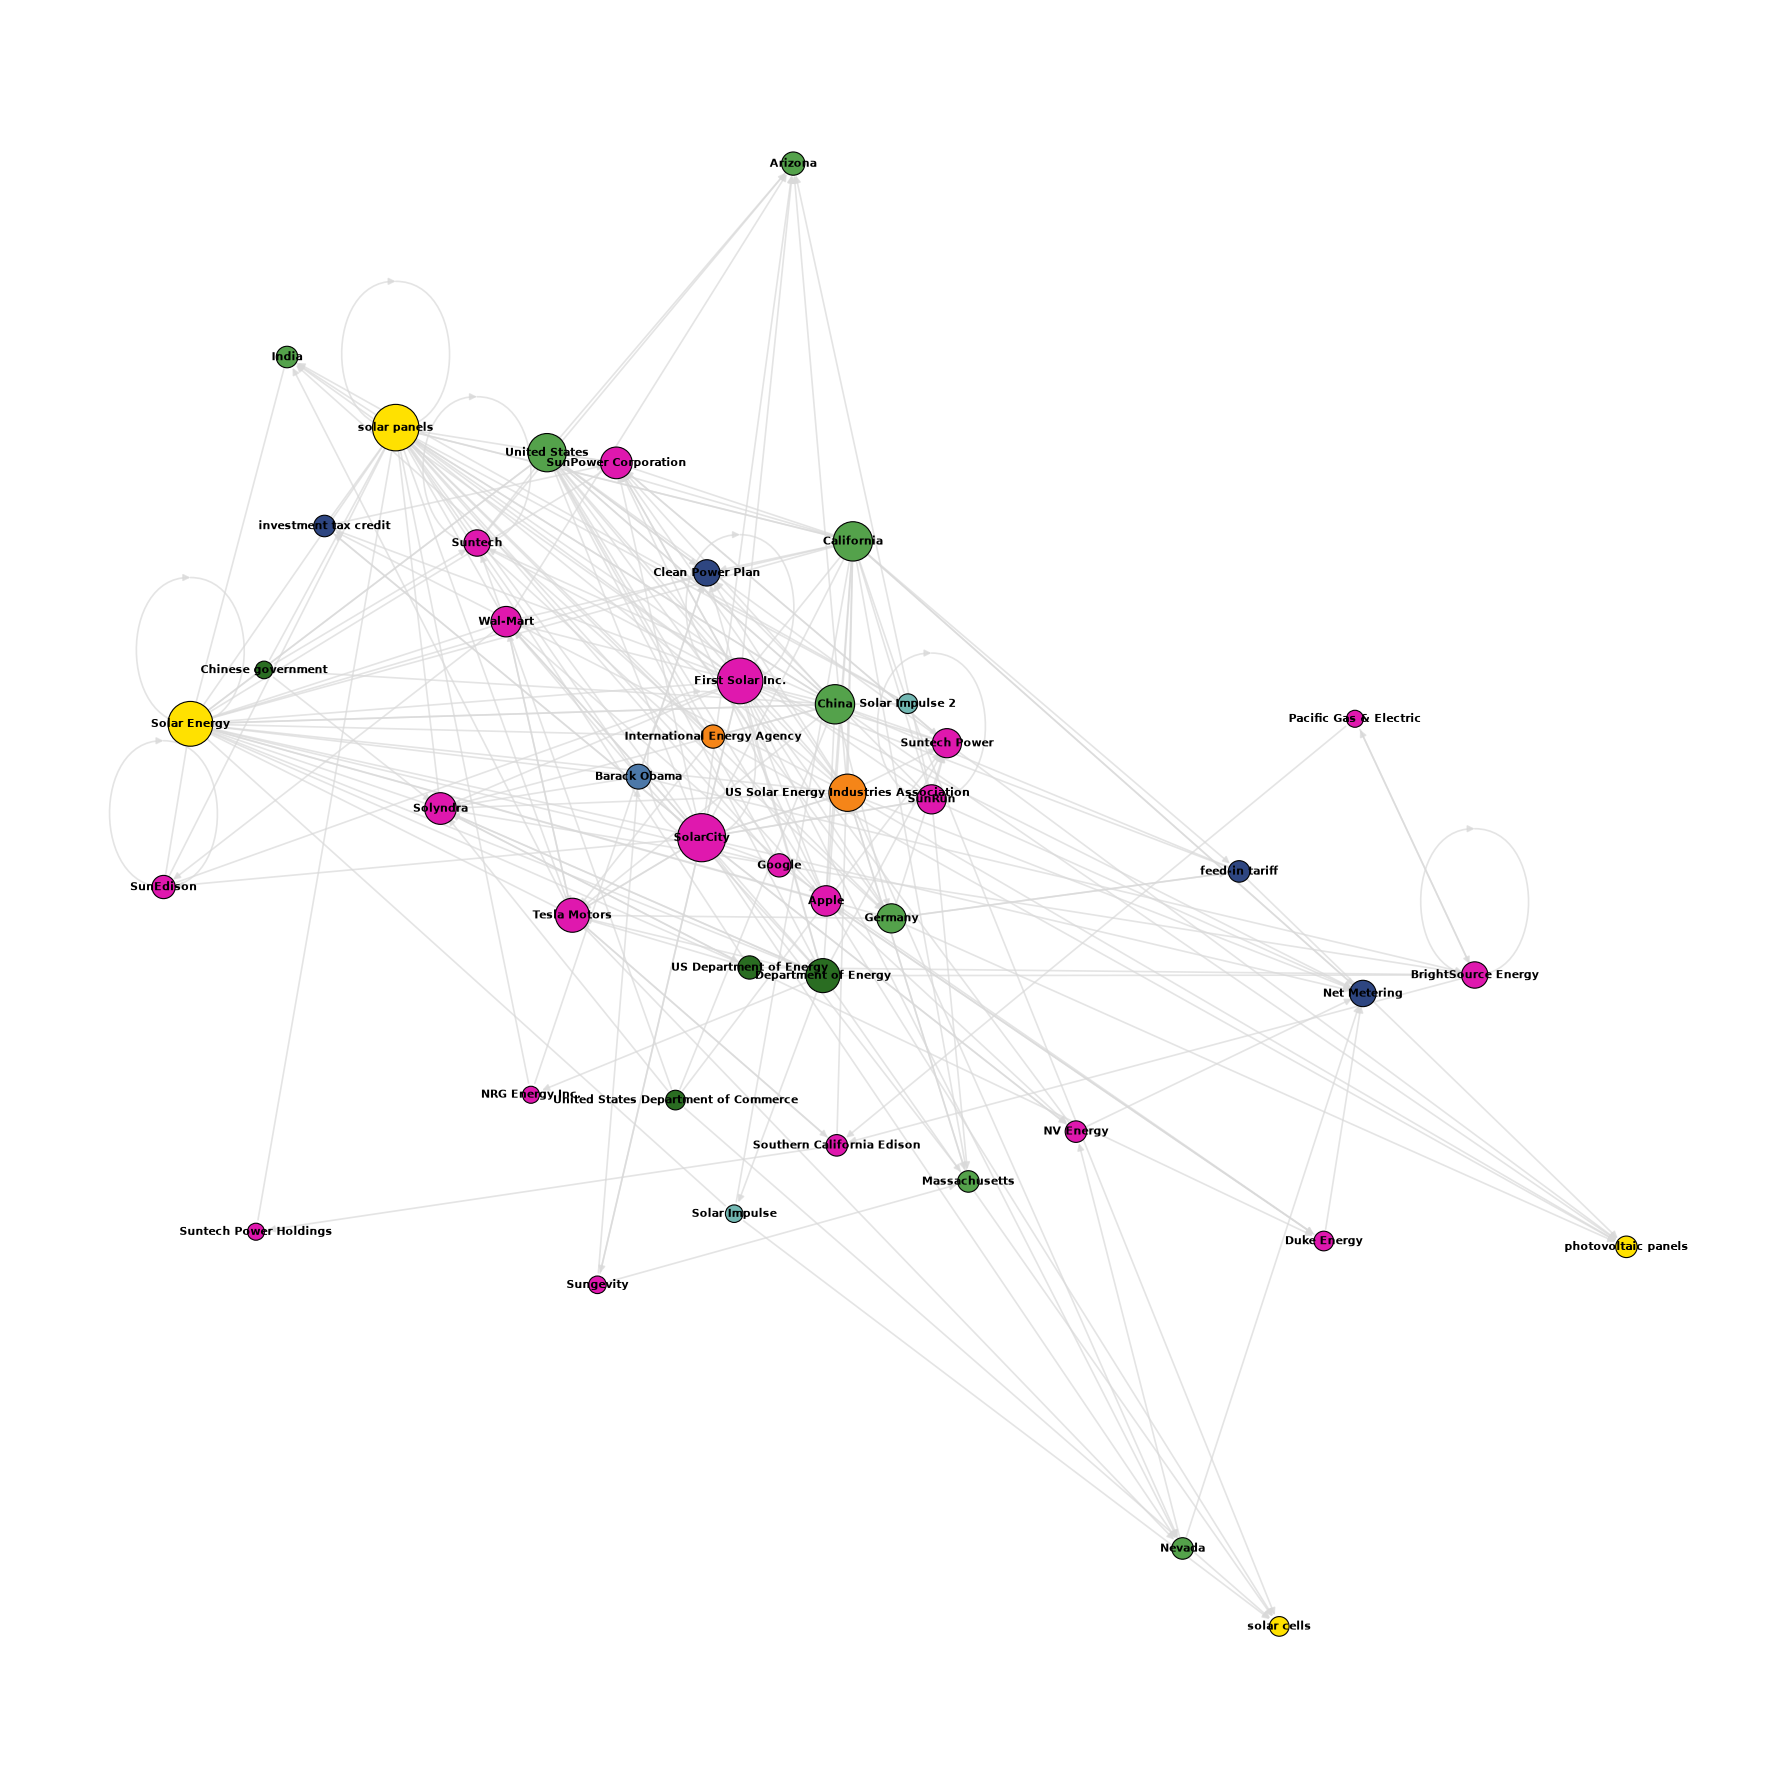

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from graph_utils import build_networkx_graph

# Reuse the filtered graph if it already exists; otherwise build it from merged CSVs.
if "filtered_graph" not in globals():
    nodes = pd.read_csv("merged_nodes.csv")
    edges = pd.read_csv("merged_edges.csv")
    _, filtered_graph, _ = build_networkx_graph(edges, nodes=nodes, min_degree=20)

# Color nodes by their type, make edges lighter, and scale nodes by degree.
node_types = nx.get_node_attributes(filtered_graph, "type")
color_map = {
    "Person": "#4C78A8",
    "Organization": "#F58518",
    "Location": "#54A24B",
    "Event": "#E45756",
    "Project": "#72B7B2",
    "Source": "#B07AA1",
    "Company": "#DF18AE",
    "Technology": "#FFE100",
    "Policy": "#2E4681",
    "GovernmentAgency": "#2A6D22",
}

node_colors = [color_map.get(node_types.get(node, ""), "#B0B0B0") for node in filtered_graph.nodes()]
degree_values = dict(filtered_graph.degree())
node_sizes = [max(150, degree_values[node] * 40) for node in filtered_graph.nodes()]

fig, ax = plt.subplots(figsize=(18, 18))
pos = nx.spring_layout(filtered_graph, k=0.8, iterations=60)

# Build label mapping using each node's stored name attribute when available.
labels = {}
for node in filtered_graph.nodes():
    node_data = filtered_graph.nodes[node]
    name = node_data.get("name") or node_data.get("properties", {}).get("name") or node
    labels[node] = name

nx.draw_networkx_edges(
    filtered_graph,
    pos,
    edge_color="#d9d9d9",
    width=1.2,
    alpha=0.7,
    arrows=True,
    ax=ax,
)

nx.draw_networkx_nodes(
    filtered_graph,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.8,
    ax=ax,
)

nx.draw_networkx_labels(
    filtered_graph,
    pos,
    labels=labels,
    font_size=8,
    font_weight="bold",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
plt.show()
